
# Лабораторная работа: Полносвязные нейронные сети на PyTorch
## Задача классификации: Срабатывания датчика дыма (smoke.csv)
## Задача регрессии:     Стоимость подержанных автомобилей (cars.csv)

In [21]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             mean_absolute_error, mean_squared_error, r2_score)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
DEVICE = torch.device("cpu")


# 1. ЗАГРУЗКА И ПРЕДОБРАБОТКА ДАННЫХ

Датасет классификации: Датчик дыма

In [22]:
smoke_df = pd.read_csv("../data/smoke.csv")
print(smoke_df.shape)
print(smoke_df.head(2))
print("\nПропуски:\n", smoke_df.isnull().sum())

(62630, 16)
   Unnamed: 0         UTC  Temperature[C]  Humidity[%]  TVOC[ppb]  eCO2[ppm]  \
0           0  1654733331          20.000        57.36        0.0      400.0   
1           1  1654733332          20.015        56.67        0.0      400.0   

    Raw H2  Raw Ethanol  Pressure[hPa]  PM1.0  PM2.5  NC0.5  NC1.0  NC2.5  \
0  12306.0        18520        939.735    0.0    0.0    0.0    0.0    0.0   
1  12345.0        18651        939.744    0.0    0.0    0.0    0.0    0.0   

   CNT Fire Alarm  
0    0         No  
1    1         No  

Пропуски:
 Unnamed: 0          0
UTC                 0
Temperature[C]    146
Humidity[%]       247
TVOC[ppb]         621
eCO2[ppm]         325
Raw H2            111
Raw Ethanol         0
Pressure[hPa]      27
PM1.0               0
PM2.5             317
NC0.5               0
NC1.0             252
NC2.5               0
CNT                 0
Fire Alarm          0
dtype: int64


In [23]:
smoke_df = smoke_df.drop(columns=["Unnamed: 0", "UTC", "CNT"], errors="ignore")

smoke_df["Fire Alarm"] = (smoke_df["Fire Alarm"].str.strip().str.lower() == "yes").astype(int)

smoke_df = smoke_df.fillna(smoke_df.median(numeric_only=True))

X_smoke = smoke_df.drop(columns=["Fire Alarm"]).values.astype(np.float32)
y_smoke = smoke_df["Fire Alarm"].values.astype(np.int64)

print(f"\nРазмер признаков: {X_smoke.shape}, классов: {np.unique(y_smoke)}")
print(f"Баланс классов: {np.bincount(y_smoke)}")


Размер признаков: (62630, 12), классов: [0 1]
Баланс классов: [17873 44757]


In [24]:
X_smoke_train, X_smoke_test, y_smoke_train, y_smoke_test = train_test_split(
    X_smoke, y_smoke, test_size=0.2, random_state=RANDOM_SEED, stratify=y_smoke
)

scaler_smoke = StandardScaler()
X_smoke_train = scaler_smoke.fit_transform(X_smoke_train).astype(np.float32)
X_smoke_test  = scaler_smoke.transform(X_smoke_test).astype(np.float32)

print(f"Train: {X_smoke_train.shape}, Test: {X_smoke_test.shape}")

Train: (50104, 12), Test: (12526, 12)


Датасет регрессии: Автомобили

In [25]:
cars_df = pd.read_csv("../data/cars.csv")
print(cars_df.shape)
print(cars_df.head(2))
print("\nПропуски:\n", cars_df.isnull().sum())

(38531, 30)
  manufacturer_name model_name transmission   color  odometer_value  \
0            Subaru    Outback    automatic  silver          190000   
1            Subaru    Outback    automatic    blue          290000   

   year_produced engine_fuel  engine_has_gas engine_type  engine_capacity  \
0           2010    gasoline           False    gasoline              2.5   
1           2002    gasoline           False    gasoline              3.0   

   ... feature_1  feature_2 feature_3 feature_4  feature_5  feature_6  \
0  ...      True       True      True     False       True      False   
1  ...      True      False     False      True       True      False   

  feature_7  feature_8  feature_9  duration_listed  
0      True       True       True               16  
1     False      False       True               83  

[2 rows x 30 columns]

Пропуски:
 manufacturer_name     0
model_name            0
transmission          0
color                 0
odometer_value        0
year_pro

In [26]:
target_col = "price_usd"

cars_df = cars_df.dropna(subset=[target_col])

q_low  = cars_df[target_col].quantile(0.01)
q_high = cars_df[target_col].quantile(0.99)
cars_df = cars_df[(cars_df[target_col] >= q_low) & (cars_df[target_col] <= q_high)]

In [27]:
drop_cols = ["manufacturer_name", "model_name", "location_region",
             "number_of_photos", "up_counter", "duration_listed"]
cars_df = cars_df.drop(columns=[c for c in drop_cols if c in cars_df.columns])

In [28]:
cat_cols = cars_df.select_dtypes(include=["object", "bool"]).columns.tolist()
if target_col in cat_cols:
    cat_cols.remove(target_col)

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    cars_df[col] = le.fit_transform(cars_df[col].astype(str))
    le_dict[col] = le

In [29]:
cars_df = cars_df.fillna(cars_df.median(numeric_only=True))

X_cars = cars_df.drop(columns=[target_col]).values.astype(np.float32)
y_cars = cars_df[target_col].values.astype(np.float32)

print(f"\nРазмер признаков: {X_cars.shape}")
print(f"Цена: min={y_cars.min():.0f}, max={y_cars.max():.0f}, mean={y_cars.mean():.0f}")


Размер признаков: (37760, 23)
Цена: min=333, max=32900, mean=6374


In [30]:
X_cars_train, X_cars_test, y_cars_train, y_cars_test = train_test_split(
    X_cars, y_cars, test_size=0.2, random_state=RANDOM_SEED
)

In [31]:
scaler_cars_X = StandardScaler()
X_cars_train = scaler_cars_X.fit_transform(X_cars_train).astype(np.float32)
X_cars_test  = scaler_cars_X.transform(X_cars_test).astype(np.float32)

scaler_cars_y = StandardScaler()
y_cars_train_sc = scaler_cars_y.fit_transform(y_cars_train.reshape(-1, 1)).ravel().astype(np.float32)
y_cars_test_sc  = scaler_cars_y.transform(y_cars_test.reshape(-1, 1)).ravel().astype(np.float32)

print(f"Train: {X_cars_train.shape}, Test: {X_cars_test.shape}")

Train: (30208, 23), Test: (7552, 23)


# 2. DATASET и DATALOADER

In [32]:
class TabularDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [33]:
BATCH_SIZE = 64

In [34]:
ds_smoke_train = TabularDataset(X_smoke_train, y_smoke_train)
ds_smoke_test  = TabularDataset(X_smoke_test,  y_smoke_test)

dl_smoke_train = DataLoader(ds_smoke_train, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
dl_smoke_test  = DataLoader(ds_smoke_test,  batch_size=BATCH_SIZE, shuffle=False)

print(f"\nДатчик дыма — батчей в эпохе (train): {len(dl_smoke_train)}")


Датчик дыма — батчей в эпохе (train): 782


In [35]:
ds_cars_train = TabularDataset(X_cars_train, y_cars_train_sc)
ds_cars_test  = TabularDataset(X_cars_test,  y_cars_test_sc)

dl_cars_train = DataLoader(ds_cars_train, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
dl_cars_test  = DataLoader(ds_cars_test,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Автомобили  — батчей в эпохе (train): {len(dl_cars_train)}")

Автомобили  — батчей в эпохе (train): 472


# 3. АРХИТЕКТУРЫ НЕЙРОННЫХ СЕТЕЙ

In [36]:
class SmokeClassifier(nn.Module):
    def __init__(self, input_dim: int, num_classes: int = 2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.net(x)

    def predict_proba(self, x):
        logits = self.forward(x)
        return torch.softmax(logits, dim=1)

In [37]:
class CarsPriceRegressor(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

In [38]:
smoke_model = SmokeClassifier(input_dim=X_smoke_train.shape[1]).to(DEVICE)
cars_model  = CarsPriceRegressor(input_dim=X_cars_train.shape[1]).to(DEVICE)

print("\n--- Архитектура классификатора (дым) ---")
print(smoke_model)
print("\n--- Архитектура регрессора (авто) ---")
print(cars_model)


--- Архитектура классификатора (дым) ---
SmokeClassifier(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=2, bias=True)
  )
)

--- Архитектура регрессора (авто) ---
CarsPriceRegressor(
  (net): Sequential(
    (0): Linear(in_features=23, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNo

# 4. ОБУЧЕНИЕ

In [39]:
def train_classifier(model, dl_train, dl_val, epochs=50, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in dl_train:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        scheduler.step()
        train_losses.append(epoch_loss / len(dl_train))

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in dl_val:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                logits   = model(X_batch)
                val_loss += criterion(logits, y_batch).item()
        val_losses.append(val_loss / len(dl_val))

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d} | train loss: {train_losses[-1]:.4f} | val loss: {val_losses[-1]:.4f}")

    return train_losses, val_losses

In [40]:
def train_regressor(model, dl_train, dl_val, epochs=60, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in dl_train:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()          # обнуляем градиенты!
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        scheduler.step()
        train_losses.append(epoch_loss / len(dl_train))

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in dl_val:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                preds    = model(X_batch)
                val_loss += criterion(preds, y_batch).item()
        val_losses.append(val_loss / len(dl_val))

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d} | train loss: {train_losses[-1]:.4f} | val loss: {val_losses[-1]:.4f}")

    return train_losses, val_losses

In [41]:
print("\n" + "="*50)
print("ОБУЧЕНИЕ КЛАССИФИКАТОРА (датчик дыма)")
print("="*50)
smoke_train_losses, smoke_val_losses = train_classifier(
    smoke_model, dl_smoke_train, dl_smoke_test, epochs=50
)

print("\n" + "="*50)
print("ОБУЧЕНИЕ РЕГРЕССОРА (цена авто)")
print("="*50)
cars_train_losses, cars_val_losses = train_regressor(
    cars_model, dl_cars_train, dl_cars_test, epochs=60
)


ОБУЧЕНИЕ КЛАССИФИКАТОРА (датчик дыма)
Epoch  10 | train loss: 0.0422 | val loss: 0.0260
Epoch  20 | train loss: 0.0297 | val loss: 0.0181
Epoch  30 | train loss: 0.0293 | val loss: 0.0179
Epoch  40 | train loss: 0.0228 | val loss: 0.0161
Epoch  50 | train loss: 0.0194 | val loss: 0.0107

ОБУЧЕНИЕ РЕГРЕССОРА (цена авто)
Epoch  10 | train loss: 0.1651 | val loss: 0.1439
Epoch  20 | train loss: 0.1561 | val loss: 0.1429
Epoch  30 | train loss: 0.1468 | val loss: 0.1389
Epoch  40 | train loss: 0.1437 | val loss: 0.1413
Epoch  50 | train loss: 0.1369 | val loss: 0.1410
Epoch  60 | train loss: 0.1357 | val loss: 0.1380


# 5. ГРАФИКИ ФУНКЦИИ ПОТЕРЬ

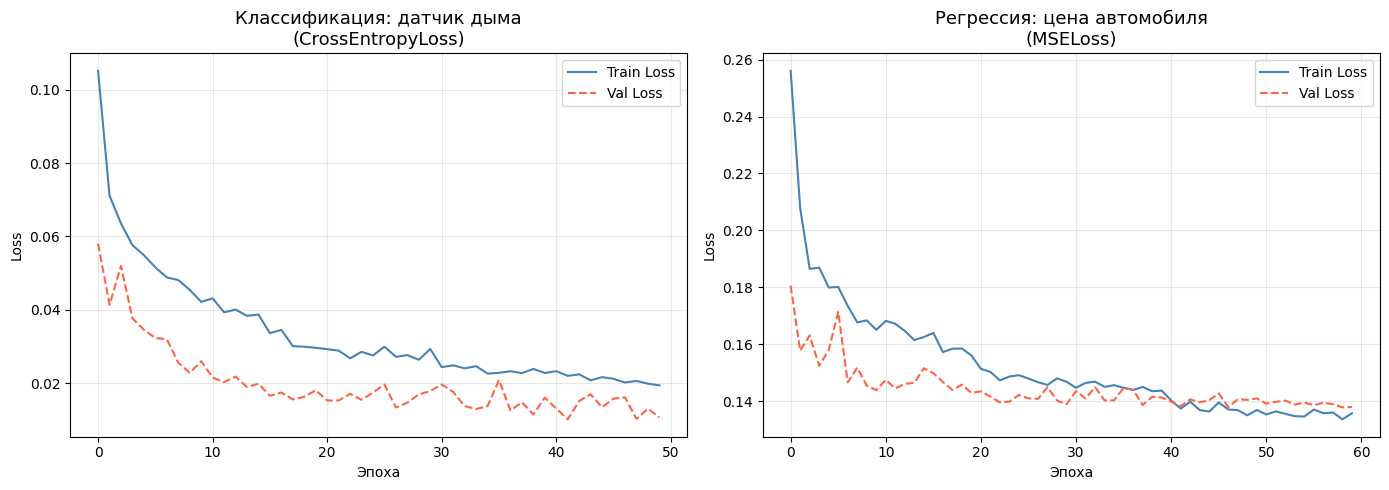

График сохранён: loss_curves.png


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(smoke_train_losses, label="Train Loss", color="steelblue")
axes[0].plot(smoke_val_losses,   label="Val Loss",   color="tomato", linestyle="--")
axes[0].set_title("Классификация: датчик дыма\n(CrossEntropyLoss)", fontsize=13)
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(cars_train_losses, label="Train Loss", color="steelblue")
axes[1].plot(cars_val_losses,   label="Val Loss",   color="tomato", linestyle="--")
axes[1].set_title("Регрессия: цена автомобиля\n(MSELoss)", fontsize=13)
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150)
plt.show()
print("График сохранён: loss_curves.png")

# 6. ОЦЕНКА КАЧЕСТВА


In [43]:
def evaluate_classifier(model, dl, device=DEVICE):
    model.eval()
    all_preds, all_labels, all_proba = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in dl:
            X_batch = X_batch.to(device)
            proba  = model.predict_proba(X_batch).cpu()
            preds  = proba.argmax(dim=1)
            all_proba.append(proba[:, 1])
            all_preds.append(preds)
            all_labels.append(y_batch)
    preds  = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    return labels, preds

In [44]:
def evaluate_regressor(model, dl, scaler_y, device=DEVICE):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in dl:
            X_batch = X_batch.to(device)
            preds   = model(X_batch).cpu()
            all_preds.append(preds)
            all_labels.append(y_batch)
    preds_sc  = torch.cat(all_preds).numpy()
    labels_sc = torch.cat(all_labels).numpy()
    preds  = scaler_y.inverse_transform(preds_sc.reshape(-1, 1)).ravel()
    labels = scaler_y.inverse_transform(labels_sc.reshape(-1, 1)).ravel()
    return labels, preds

In [45]:
# --- Классификация ---
y_true_cls, y_pred_cls = evaluate_classifier(smoke_model, dl_smoke_test)

print("\n" + "="*50)
print("МЕТРИКИ: КЛАССИФИКАЦИЯ (датчик дыма, тестовая выборка)")
print("="*50)
print(f"Accuracy : {accuracy_score(y_true_cls, y_pred_cls):.4f}")
print(f"F1-score : {f1_score(y_true_cls, y_pred_cls, average='weighted'):.4f}")
print("\nПодробный отчёт:")
print(classification_report(y_true_cls, y_pred_cls, target_names=["No Fire", "Fire"]))


МЕТРИКИ: КЛАССИФИКАЦИЯ (датчик дыма, тестовая выборка)
Accuracy : 0.9962
F1-score : 0.9962

Подробный отчёт:
              precision    recall  f1-score   support

     No Fire       1.00      0.99      0.99      3575
        Fire       1.00      1.00      1.00      8951

    accuracy                           1.00     12526
   macro avg       1.00      0.99      1.00     12526
weighted avg       1.00      1.00      1.00     12526



In [46]:
# --- Регрессия ---
y_true_reg, y_pred_reg = evaluate_regressor(cars_model, dl_cars_test, scaler_cars_y)

print("="*50)
print("МЕТРИКИ: РЕГРЕССИЯ (цена авто, тестовая выборка)")
print("="*50)
mae  = mean_absolute_error(y_true_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_true_reg, y_pred_reg))
r2   = r2_score(y_true_reg, y_pred_reg)
mape = np.mean(np.abs((y_true_reg - y_pred_reg) / (y_true_reg + 1e-8))) * 100

print(f"MAE  : {mae:.2f} USD")
print(f"RMSE : {rmse:.2f} USD")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f} %")

МЕТРИКИ: РЕГРЕССИЯ (цена авто, тестовая выборка)
MAE  : 1302.75 USD
RMSE : 2054.51 USD
R²   : 0.8647
MAPE : 33.53 %


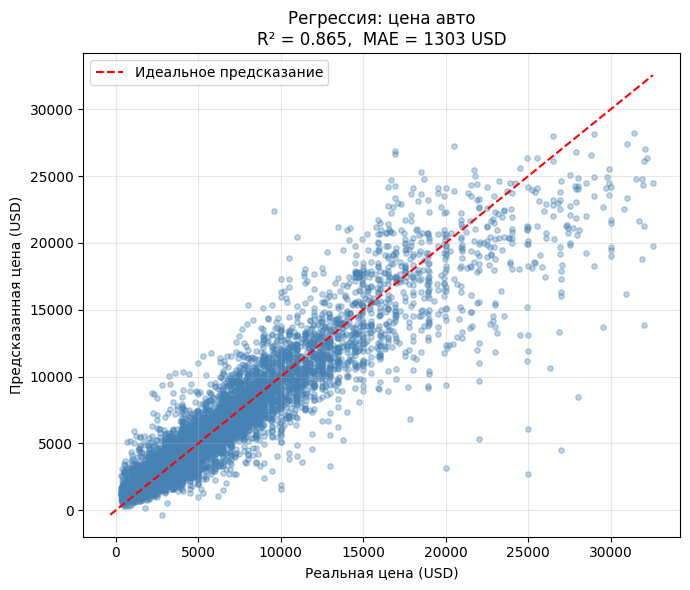

График сохранён: regression_scatter.png


In [47]:
# --- График предсказания vs реальность (регрессия) ---
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_true_reg, y_pred_reg, alpha=0.35, s=15, color="steelblue")
lim = [min(y_true_reg.min(), y_pred_reg.min()),
       max(y_true_reg.max(), y_pred_reg.max())]
ax.plot(lim, lim, "r--", linewidth=1.5, label="Идеальное предсказание")
ax.set_xlabel("Реальная цена (USD)")
ax.set_ylabel("Предсказанная цена (USD)")
ax.set_title(f"Регрессия: цена авто\nR² = {r2:.3f},  MAE = {mae:.0f} USD")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("regression_scatter.png", dpi=150)
plt.show()
print("График сохранён: regression_scatter.png")